<a href="https://colab.research.google.com/github/prashant200487/BookStore2/blob/main/AnimalSound.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#libraries
!pip install librosa soundfile torch torchaudio numpy matplotlib tqdm -q
print("Done!")

Done!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#set the path
import os
ESC50_DIR = "/content/drive/MyDrive/ESC-50-master (1)/ESC-50-master"
print(os.listdir(ESC50_DIR))
print("\nAudio folder:", os.listdir(os.path.join(ESC50_DIR, "audio"))[:5])
print("Meta folder:",  os.listdir(os.path.join(ESC50_DIR, "meta")))

['pytest.ini', 'requirements.txt', '.gitignore', 'esc50.gif', 'LICENSE', 'README.md', 'tests', 'meta', 'audio', '.github', '.circleci']

Audio folder: ['3-151213-A-24.wav', '3-151081-A-20.wav', '3-150979-A-40.wav', '3-154957-A-1.wav', '3-154781-A-32.wav']
Meta folder: ['esc50-human.xlsx', 'esc50.csv']


In [ ]:
#Data organize kro
import shutil
import pandas as pd

KEEP_CLASSES = ["dog", "cat", "frog", "crow", "crickets", "cow", "pig", "insects"]

meta_path = os.path.join(ESC50_DIR, "meta", "esc50.csv")
audio_dir = os.path.join(ESC50_DIR, "audio")
out_dir   = "/content/data"

df = pd.read_csv(meta_path)
df = df[df["category"].isin(KEEP_CLASSES)]

print(f"Total files: {len(df)}")
print(df["category"].value_counts())

for _, row in df.iterrows():
    src     = os.path.join(audio_dir, row["filename"])
    dst_dir = os.path.join(out_dir, row["category"])
    os.makedirs(dst_dir, exist_ok=True)
    dst     = os.path.join(dst_dir, row["filename"])
    if not os.path.exists(dst):
        shutil.copy2(src, dst)

print("\n Data organized!")
for cls in KEEP_CLASSES:
    path = os.path.join(out_dir, cls)
    if os.path.isdir(path):
        print(f"  {cls:<12}: {len(os.listdir(path))} files")

Total files: 320
category
dog         40
crow        40
frog        40
cow         40
insects     40
pig         40
cat         40
crickets    40
Name: count, dtype: int64

 Data organized!
  dog         : 40 files
  cat         : 40 files
  frog        : 40 files
  crow        : 40 files
  crickets    : 40 files
  cow         : 40 files
  pig         : 40 files
  insects     : 40 files


In [ ]:
#Feature Extraction
import numpy as np
import librosa
import torch
import cv2

SAMPLE_RATE = 22050
DURATION    = 2.0
N_MELS      = 128
HOP_LENGTH  = 512
N_FFT       = 2048

def load_audio(file_path):
    y, _ = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION, mono=True)
    target_len = int(SAMPLE_RATE * DURATION)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y.astype(np.float32)

def audio_to_melspec(y):
    mel     = librosa.feature.melspectrogram(
        y=y, sr=SAMPLE_RATE, n_mels=N_MELS,
        n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    log_mel = cv2.resize(log_mel, (128, 128))
    #Normalization
    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
    return log_mel.astype(np.float32)

print(" Feature extractor ready!")

# Testing
import glob
test_files = glob.glob("/content/data/dog/*.wav")
if test_files:
    y    = load_audio(test_files[0])
    spec = audio_to_melspec(y)
    print(f"Waveform shape : {y.shape}")
    print(f"Spectrogram shape: {spec.shape}")

 Feature extractor ready!
Waveform shape : (44100,)
Spectrogram shape: (128, 128)


/tmp/ipykernel_21322/3651301956.py:18: UserWarning: Glyph 128062 (\N{PAW PRINTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21322/3651301956.py:19: UserWarning: Glyph 128062 (\N{PAW PRINTS}) missing from font(s) DejaVu Sans.
  plt.savefig("spectrograms.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128062 (\N{PAW PRINTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


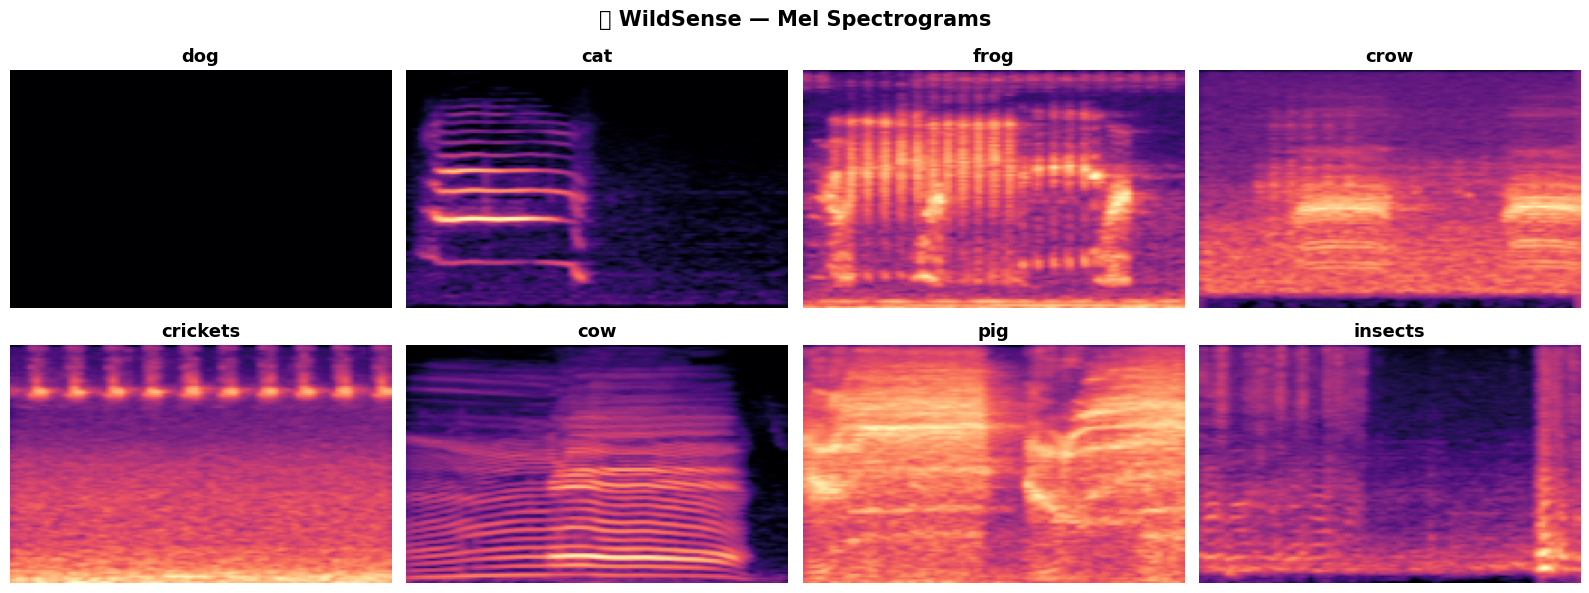

 Spectrograms plotted!


In [ ]:
import matplotlib.pyplot as plt
import glob

CLASSES = ["dog", "cat", "frog", "crow", "crickets", "cow", "pig", "insects"]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for ax, cls in zip(axes.flatten(), CLASSES):
    files = glob.glob(f"/content/data/{cls}/*.wav")
    if files:
        y    = load_audio(files[0])
        spec = audio_to_melspec(y)
        ax.imshow(spec, aspect="auto", origin="lower", cmap="magma")
        ax.set_title(cls, fontsize=13, fontweight="bold")
        ax.axis("off")

plt.suptitle("🐾 WildSense — Mel Spectrograms", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("spectrograms.png", dpi=150)
plt.show()
print(" Spectrograms plotted!")


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
    def forward(self, x):
        return self.block(x)

class WildSenseCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(1,  32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.gap(self.encoder(x)))

# Test
model = WildSenseCNN(num_classes=8)
dummy = torch.randn(4, 1, 128, 128)
out   = model(dummy)
print(f" Model output shape: {out.shape}")   # (4, 8) hona chahiye
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

 Model output shape: torch.Size([4, 8])
Total parameters: 1,206,568


In [ ]:
from torch.utils.data import Dataset, DataLoader, random_split

class AnimalSoundDataset(Dataset):
    def __init__(self, data_dir, augment=False):
        self.samples  = []
        self.labels   = []
        self.augment  = augment
        self.classes  = sorted([
            d for d in os.listdir(data_dir)
            if os.path.isdir(os.path.join(data_dir, d))
        ])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        for cls in self.classes:
            cls_dir = os.path.join(data_dir, cls)
            for f in os.listdir(cls_dir):
                if f.lower().endswith((".wav", ".mp3", ".ogg")):
                    self.samples.append(os.path.join(cls_dir, f))
                    self.labels.append(self.class_to_idx[cls])

        print(f" Dataset ready!")
        print(f"   Total files : {len(self.samples)}")
        print(f"   Classes     : {self.classes}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        y = load_audio(self.samples[idx])

        if self.augment:
            gain  = np.random.uniform(0.7, 1.3)
            noise = np.random.randn(len(y)) * 0.005
            y     = (y * gain + noise).astype(np.float32)

        spec = audio_to_melspec(y)
        x    = torch.tensor(spec).unsqueeze(0)  # (1, 128, 128)
        return x, self.labels[idx]


# Dataset banao
dataset = AnimalSoundDataset("/content/data", augment=True)

# Test
sample_x, sample_y = dataset[0]
print(f"\n   Sample shape : {sample_x.shape}")
print(f"   Sample label : {sample_y} = '{dataset.classes[sample_y]}'")

 Dataset ready!
   Total files : 320
   Classes     : ['cat', 'cow', 'crickets', 'crow', 'dog', 'frog', 'insects', 'pig']

   Sample shape : torch.Size([1, 128, 128])
   Sample label : 0 = 'cat'


In [ ]:
from tqdm.notebook import tqdm

EPOCHS     = 30
BATCH_SIZE = 32
LR         = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")  # GPU hoga toh 'cuda' aayega

# Train/Val split 80/20
n_val   = int(len(dataset) * 0.2)
n_train = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

model     = WildSenseCNN(num_classes=len(dataset.classes)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

history = {"train_acc": [], "val_acc": [], "loss": []}
best_val = 0.0

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
        x, y    = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits  = model(x)
        loss    = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += len(y)

    scheduler.step()

    # ── Validate ──
    model.eval()
    vc, vt = 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            vc  += (model(x).argmax(1) == y).sum().item()
            vt  += len(y)

    t_acc = 100 * correct / total
    v_acc = 100 * vc / vt
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)
    history["loss"].append(total_loss / total)

    # Best model save
    if v_acc > best_val:
        best_val = v_acc
        os.makedirs("/content/models", exist_ok=True)
        torch.save({
            "model_state": model.state_dict(),
            "classes":     dataset.classes,
            "num_classes": len(dataset.classes),
        }, "/content/models/wildsense_best.pth")
        print(f"Epoch {epoch:02d} | loss={total_loss/total:.4f} | train={t_acc:.1f}% | val={v_acc:.1f}% saved")
    else:
        print(f"Epoch {epoch:02d} | loss={total_loss/total:.4f} | train={t_acc:.1f}% | val={v_acc:.1f}%")

print(f"\n Training done! Best val accuracy: {best_val:.1f}%")

Device: cuda


Epoch 1/30:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 01 | loss=1.8877 | train=32.8% | val=7.8% saved


Epoch 2/30:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 02 | loss=1.5144 | train=47.7% | val=7.8%


...

Epoch 28 | loss=0.0585 | train=100.0% | val=89.1%


Epoch 29/30:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 29 | loss=0.0707 | train=99.6% | val=92.2%


Epoch 30/30:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 30 | loss=0.0661 | train=98.8% | val=92.2%

 Training done! Best val accuracy: 93.8%


/tmp/ipykernel_21322/1506240866.py:45: UserWarning: Glyph 128062 (\N{PAW PRINTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21322/1506240866.py:46: UserWarning: Glyph 128062 (\N{PAW PRINTS}) missing from font(s) DejaVu Sans.
  plt.savefig("results.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128062 (\N{PAW PRINTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


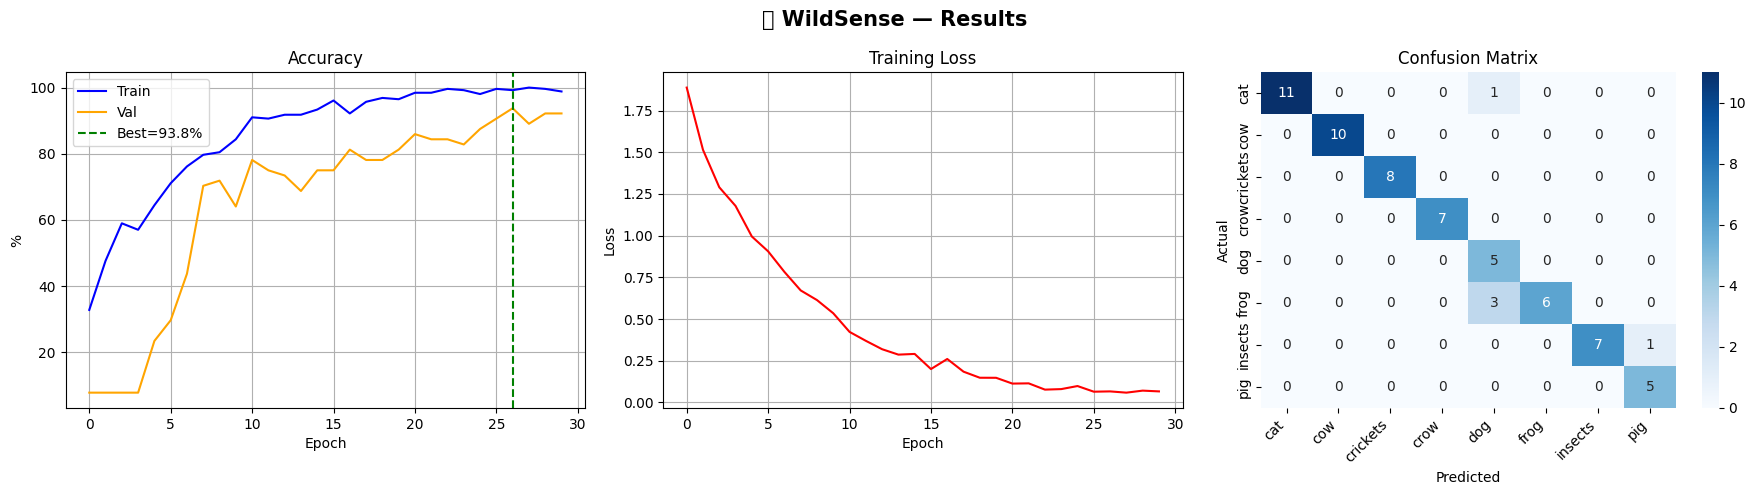


📊 Classification Report:
              precision    recall  f1-score   support

         cat       1.00      0.92      0.96        12
         cow       1.00      1.00      1.00        10
    crickets       1.00      1.00      1.00         8
        crow       1.00      1.00      1.00         7
         dog       0.56      1.00      0.71         5
        frog       1.00      0.67      0.80         9
     insects       1.00      0.88      0.93         8
         pig       0.83      1.00      0.91         5

    accuracy                           0.92        64
   macro avg       0.92      0.93      0.91        64
weighted avg       0.95      0.92      0.93        64


🏆 Best Val Accuracy: 93.8%


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# ── Training Graphs ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_acc"], label="Train", color="blue")
axes[0].plot(history["val_acc"],   label="Val",   color="orange")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("%"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history["loss"], color="red")
axes[1].set_title("Training Loss"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss"); axes[1].grid(True)

# Best accuracy line
best_epoch = history["val_acc"].index(max(history["val_acc"]))
axes[0].axvline(x=best_epoch, color="green", linestyle="--", label=f"Best={max(history['val_acc']):.1f}%")
axes[0].legend()

# ── Confusion Matrix ──
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        preds = model(x).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y.numpy())

cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=dataset.classes,
            yticklabels=dataset.classes,
            ax=axes[2])
axes[2].set_title("Confusion Matrix")
axes[2].set_ylabel("Actual")
axes[2].set_xlabel("Predicted")
plt.setp(axes[2].get_xticklabels(), rotation=45, ha="right")

plt.suptitle("🐾 WildSense — Results", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("results.png", dpi=150)
plt.show()

# ── Classification Report ──
print("\n📊 Classification Report:")
print(classification_report(all_true, all_preds, target_names=dataset.classes))
print(f"\n🏆 Best Val Accuracy: {max(history['val_acc']):.1f}%")

In [ ]:
import glob

def predict_file(file_path):
    checkpoint = torch.load("/content/models/wildsense_best.pth", map_location=device)
    classes    = checkpoint["classes"]
    mdl        = WildSenseCNN(num_classes=len(classes)).to(device)
    mdl.load_state_dict(checkpoint["model_state"])
    mdl.eval()

    y    = load_audio(file_path)
    spec = audio_to_melspec(y)
    x    = torch.tensor(spec).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = F.softmax(mdl(x), dim=1)[0]

    top3 = probs.topk(3)

    print(f"\n🎵 File: {os.path.basename(file_path)}")
    print("─" * 40)
    for conf, idx in zip(top3.values, top3.indices):
        cls = classes[int(idx)]
        bar = "█" * int(float(conf) * 25)
        print(f"  {cls:<12} {float(conf):.1%}  {bar}")

    # Distance estimate
    rms_db = 20 * np.log10(np.sqrt(np.mean(y**2)) + 1e-10)
    if   rms_db > -20: dist = "🔴 Near"
    elif rms_db > -40: dist = "🟡 Medium"
    else:              dist = "🟢 Far"
    print(f"\n  Distance : {dist}  ({rms_db:.1f} dB)")


# ── Option 1: Dataset se test karo ──
print("=== Testing from dataset ===")
for cls in dataset.classes:
    files = glob.glob(f"/content/data/{cls}/*.wav")
    if files:
        predict_file(files[0])
        break

# ── Option 2: Apni file upload karke test karo ──
print("\n=== Upload your own sound file ===")
from google.colab import files
uploaded = files.upload()
for filename in uploaded.keys():
    predict_file(filename)

=== Testing from dataset ===

🎵 File: 5-214759-B-5.wav
────────────────────────────────────────
  cow          96.3%  ████████████████████████
  cat          3.6%  
  pig          0.1%  

  Distance : 🟡 Medium  (-22.1 dB)

=== Upload your own sound file ===


Saving 5-263775-B-26.wav to 5-263775-B-26.wav

🎵 File: 5-263775-B-26.wav
────────────────────────────────────────
  dog          77.9%  ███████████████████
  pig          21.2%  █████
  frog         0.4%  

  Distance : 🔴 Near  (-13.8 dB)
